# Trabajo Práctico N° 1

## Ejercicio 1: Análisis de Datos COVID-19 en Bahía Blanca

### Contexto
Se dispone de dos datasets sobre la situación epidemiológica y sanitaria relacionada con el COVID-19 en Bahía Blanca:

1. **`casos_covid_bahia.csv`** - Situación epidemiológica (casos, fallecidos, etc.)
2. **`camas_covid_bahia.csv`** - Situación sanitaria (camas ocupadas, disponibles, etc.)

Fuente: https://datos.bahia.gob.ar/dataset?groups=covid19

### Consigna
Las variables en estos datasets son **discretas** (conteos de personas), pero en muchos casos se puede aplicar razonablemente el análisis estadístico como si fuesen valores continuos.

Realice un análisis exploratorio que responda:

1. **¿Hay variables que puedan ser razonablemente consideradas con distribución normal?**
   - Justifique usando métodos gráficos (histogramas, gráficos Q-Q) y pruebas estadísticas apropiadas.
   
2. **¿Hay variables que presenten un comportamiento "sospechoso"?**
   - Identifique y analice posibles outliers, sesgos pronunciados, discretización excesiva, o patrones no aleatorios.
   - Proponga posibles explicaciones para estos comportamientos.to sospechoso?

In [1]:
# Import libraries
%matplotlib inline

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm

from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
from sklearn.mixture import GaussianMixture

In [2]:
from IPython.display import display, HTML

display(HTML("""
<style>
.output_scroll {
    height: auto !important;
    max-height: none !important;
}
</style>
"""))

In [3]:
COVID_PATH = os.path.join(os.getcwd(), "data", "casos_covid_bahia.csv")
CAMAS_PATH = os.path.join(os.getcwd(), "data", "camas_covid_bahia.csv")

In [4]:
df_covid = pd.read_csv(COVID_PATH)
df_camas = pd.read_csv(CAMAS_PATH)

In [5]:
df_covid.head()

,fecha,confirmados,activos,recuperados,decesos,descartados,sospechosos,contencion_psicologica,monitoreo_epidemiologico,aislamiento_por_contacto_estrecho,aprehendidos
0,2020-06-30,106,29,71,6,574,23,342,2338,181,0
1,2020-07-01,114,31,77,6,581,22,342,2207,172,0
2,2020-07-02,124,40,78,6,588,24,356,2162,176,0
3,2020-07-03,137,53,78,6,606,31,356,2353,190,0
4,2020-07-04,154,70,78,6,622,31,356,2377,214,0


In [6]:
df_camas.head()

,informeNumero,fecha,total_camas_hospitales,camas_ocupadas_hospitales,porcentaje_ocupacion_camas_hospitales,camas_covid,camas_sospechosos_covid,camas_confirmados_covid,porcentaje_ocupacion_camas_covid,uti_covid_totales,uti_covid_ocupadas,respiradores_totales,respiradores_ocupados,respiradores_covid_totales,respiradores_covid_ocupados,total_camas_ucma,total_camas_ocupadas_ucma,sedes_ucma,observaciones
0,131,2020-09-25,848,401,47,163,42,84,77,32,24,142,41,69,25,147,19,4,NaN
1,130,2020-09-24,848,391,46,163,25,86,68,32,17,142,39,69,21,147,21,4,NaN
2,129,2020-09-23,848,402,47,163,21,85,65,32,22,142,42,71,23,147,19,4,NaN
3,128,2020-09-22,848,391,46,163,30,83,69,32,21,142,43,72,24,147,15,4,NaN
4,127,2020-09-21,848,368,43,163,32,82,69,32,24,142,40,72,24,147,10,4,NaN


In [7]:
df_covid["fecha"] = pd.to_datetime(df_covid["fecha"], errors="coerce")
df_camas["fecha"] = pd.to_datetime(df_camas["fecha"], errors="coerce")

In [8]:
df_covid = df_covid.sort_values("fecha").reset_index(drop=True)
df_camas = df_camas.sort_values("fecha").reset_index(drop=True)

In [9]:
def to_numeric_safe(df: pd.DataFrame, exclude=("fecha", "observaciones")):
    df = df.copy()
    for c in df.columns:
        if c in exclude:
            continue
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

df_covid = to_numeric_safe(df_covid)
df_camas = to_numeric_safe(df_camas)

In [10]:
df_covid

,fecha,confirmados,activos,recuperados,decesos,descartados,sospechosos,contencion_psicologica,monitoreo_epidemiologico,aislamiento_por_contacto_estrecho,aprehendidos
0,2020-06-30,106,29,71,6,574,23,342,2338,181,0
1,2020-07-01,114,31,77,6,581,22,342,2207,172,0
2,2020-07-02,124,40,78,6,588,24,356,2162,176,0
3,2020-07-03,137,53,78,6,606,31,356,2353,190,0
4,2020-07-04,154,70,78,6,622,31,356,2377,214,0
...,...,...,...,...,...,...,...,...,...,...,...
83,2020-09-21,2589,1319,1209,61,3557,303,417,1261,510,0
84,2020-09-22,2714,1371,1282,61,3615,292,417,1197,554,0
85,2020-09-23,2841,1464,1313,64,3658,286,417,1206,562,0
86,2020-09-24,2906,1474,1366,66,3682,331,417,1221,562,0


In [11]:
df_camas

,informeNumero,fecha,total_camas_hospitales,camas_ocupadas_hospitales,porcentaje_ocupacion_camas_hospitales,camas_covid,camas_sospechosos_covid,camas_confirmados_covid,porcentaje_ocupacion_camas_covid,uti_covid_totales,uti_covid_ocupadas,respiradores_totales,respiradores_ocupados,respiradores_covid_totales,respiradores_covid_ocupados,total_camas_ucma,total_camas_ocupadas_ucma,sedes_ucma,observaciones
0,1,2020-06-30,848,347,40,155,15,10,16,32,1,143,23,0,0,137,0,3,NaN
1,7,2020-07-01,848,386,45,155,12,12,15,32,2,143,24,0,0,137,0,3,NaN
2,8,2020-07-02,848,358,42,155,14,14,18,32,4,143,25,0,0,137,0,3,NaN
3,9,2020-07-03,848,349,41,155,18,13,20,32,4,143,25,0,0,137,0,3,NaN
4,10,2020-07-04,848,343,40,155,14,14,18,32,3,143,22,0,0,137,0,3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,127,2020-09-21,848,368,43,163,32,82,69,32,24,142,40,72,24,147,10,4,NaN
84,128,2020-09-22,848,391,46,163,30,83,69,32,21,142,43,72,24,147,15,4,NaN
85,129,2020-09-23,848,402,47,163,21,85,65,32,22,142,42,71,23,147,19,4,NaN
86,130,2020-09-24,848,391,46,163,25,86,68,32,17,142,39,69,21,147,21,4,NaN


In [12]:
df_covid2 = df_covid.copy()
for col in ["confirmados", "recuperados", "decesos", "descartados"]:
    if col in df_covid2.columns:
        df_covid2[f"delta_{col}"] = df_covid2[col].diff() # permite calcular los "deltas" diarios

# Hallazgos Iniciales

- **Misma dimensionalidad:** Ambos datasets tienen la misma cantidad de filas.
- **Alineación temporal:** Los datos están ordenados cronológicamente y comparten el mismo rango de fechas (fecha inicial y fecha final).inal).

# Se decide "combinar" ambos datasets, mediante la unión "INNER JOIN", la cual devuelve una tabla resultante que contiene solo las filas con fechas coincidentes en ambos conjuntos de datos.

In [13]:
df = df_covid2.merge(df_camas, on="fecha", how="inner", suffixes=("_covid", "_camas"))

In [14]:
df

,fecha,confirmados,activos,recuperados,decesos,descartados,sospechosos,contencion_psicologica,monitoreo_epidemiologico,aislamiento_por_contacto_estrecho,...,uti_covid_totales,uti_covid_ocupadas,respiradores_totales,respiradores_ocupados,respiradores_covid_totales,respiradores_covid_ocupados,total_camas_ucma,total_camas_ocupadas_ucma,sedes_ucma,observaciones
0,2020-06-30,106,29,71,6,574,23,342,2338,181,...,32,1,143,23,0,0,137,0,3,NaN
1,2020-07-01,114,31,77,6,581,22,342,2207,172,...,32,2,143,24,0,0,137,0,3,NaN
2,2020-07-02,124,40,78,6,588,24,356,2162,176,...,32,4,143,25,0,0,137,0,3,NaN
3,2020-07-03,137,53,78,6,606,31,356,2353,190,...,32,4,143,25,0,0,137,0,3,NaN
4,2020-07-04,154,70,78,6,622,31,356,2377,214,...,32,3,143,22,0,0,137,0,3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,2020-09-21,2589,1319,1209,61,3557,303,417,1261,510,...,32,24,142,40,72,24,147,10,4,NaN
84,2020-09-22,2714,1371,1282,61,3615,292,417,1197,554,...,32,21,142,43,72,24,147,15,4,NaN
85,2020-09-23,2841,1464,1313,64,3658,286,417,1206,562,...,32,22,142,42,71,23,147,19,4,NaN
86,2020-09-24,2906,1474,1366,66,3682,331,417,1221,562,...,32,17,142,39,69,21,147,21,4,NaN


In [15]:
print("Rango de fechas unido:", df["fecha"].min(), "->", df["fecha"].max())
print("Filas:", len(df), "Columnas:", df.shape[1])

Rango de fechas unido: 2020-06-30 00:00:00 -> 2020-09-25 00:00:00
Filas: 88 Columnas: 33


In [16]:
numeric_columns_list = df.select_dtypes(include="number").columns.tolist()
print(numeric_columns_list)

['confirmados', 'activos', 'recuperados', 'decesos', 'descartados', 'sospechosos', 'contencion_psicologica', 'monitoreo_epidemiologico', 'aislamiento_por_contacto_estrecho', 'aprehendidos', 'delta_confirmados', 'delta_recuperados', 'delta_decesos', 'delta_descartados', 'informeNumero', 'total_camas_hospitales', 'camas_ocupadas_hospitales', 'porcentaje_ocupacion_camas_hospitales', 'camas_covid', 'camas_sospechosos_covid', 'camas_confirmados_covid', 'porcentaje_ocupacion_camas_covid', 'uti_covid_totales', 'uti_covid_ocupadas', 'respiradores_totales', 'respiradores_ocupados', 'respiradores_covid_totales', 'respiradores_covid_ocupados', 'total_camas_ucma', 'total_camas_ocupadas_ucma', 'sedes_ucma']


# Como son muchas las variables a analizar, se adopta la siguiente decisión:

## Se elegirá aquellas que posean: relevancia → calidad → representatividad

### 1. Calidad (datos utilizables)

Se filtra por:

% de faltantes bajo

varianza > 0 (no constantes)

cantidad de valores únicos suficiente (si todo es el mismo número, no aporta)

In [17]:
def select_candidates(df, exclude=("fecha", "observaciones"), min_non_null=0.9, min_unique=5):
    
    num_cols = df.select_dtypes(include=[np.number]).columns # Se seleccionan variables numéricas
    num_cols = [c for c in num_cols if c not in exclude]

    stats = []
    n = len(df)

    for c in num_cols:
        s = df[c]
        non_null_ratio = s.notna().mean()
        nunique = s.nunique(dropna=True)
        std = s.std()

        stats.append({
            "variable": c,
            "non_null_%": non_null_ratio * 100,
            "nunique": int(nunique),
            "std": float(std) if pd.notna(std) else np.nan,
            "zeros_%": float((s.dropna().eq(0).mean() * 100)) if s.notna().any() else np.nan
        })

    meta = pd.DataFrame(stats).sort_values(["non_null_%", "std"], ascending=[False, False])

    # filtros de calidad
    candidates = meta[
        (meta["non_null_%"] >= min_non_null * 100) & # porcentaje mínimo de datos no nulos
        (meta["nunique"] >= min_unique) & ## cantidad mínima de valores distintos que debe tener una variable
        (meta["std"] > 0)
    ].copy()

    return meta, candidates

meta, candidates = select_candidates(df, min_non_null=0.85, min_unique=5)

print("Metadata de columnas numéricas")
display(meta)

print("Candidatas (por calidad)")
display(candidates)

Metadata de columnas numéricas


,variable,non_null_%,nunique,std,zeros_%
4,descartados,100.000000,88,951.537510,0.000000
0,confirmados,100.000000,88,741.951512,0.000000
1,activos,100.000000,78,377.382561,0.000000
2,recuperados,100.000000,85,369.502430,0.000000
7,monitoreo_epidemiologico,100.000000,82,289.810181,0.000000
15,total_camas_hospitales,100.000000,8,155.002113,3.409091
8,aislamiento_por_contacto_estrecho,100.000000,74,113.161691,0.000000
5,sospechosos,100.000000,76,101.144080,0.000000
16,camas_ocupadas_hospitales,100.000000,69,77.216502,3.409091
14,informeNumero,100.000000,88,42.113072,0.000000


Candidatas (por calidad)


,variable,non_null_%,nunique,std,zeros_%
4,descartados,100.000000,88,951.537510,0.000000
0,confirmados,100.000000,88,741.951512,0.000000
1,activos,100.000000,78,377.382561,0.000000
2,recuperados,100.000000,85,369.502430,0.000000
7,monitoreo_epidemiologico,100.000000,82,289.810181,0.000000
15,total_camas_hospitales,100.000000,8,155.002113,3.409091
8,aislamiento_por_contacto_estrecho,100.000000,74,113.161691,0.000000
5,sospechosos,100.000000,76,101.144080,0.000000
16,camas_ocupadas_hospitales,100.000000,69,77.216502,3.409091
14,informeNumero,100.000000,88,42.113072,0.000000


In [18]:
excluidas = [var for var in meta["variable"].to_list() if var not in candidates["variable"].to_list()]
print(f"Las variables excluidas en este primer paso son: {' - '.join(excluidas)}")

Las variables excluidas en este primer paso son: respiradores_totales - contencion_psicologica - total_camas_ucma - sedes_ucma - aprehendidos


### ¿Por qué es importante eliminar variables con muchos valores faltantes?

- rompen las visualizaciones y dificultan su interpretación,
- sesgan las estadísticas descriptivas,
- introducen ambigüedad y confusión en el análisis exploratorio.

### Si una variable toma menos de 5 valores distintos, probablemente no aporta mucho al análisis continuo.

### (meta["std"] > 0) significa descartar variables sin variación, porque no aportan información analítica.

## 2. Representatividad

### Evitar redundancia

Muchas variables son casi lo mismo (altamente correlacionadas).

In [19]:
def reduce_by_correlation(df, cols, threshold=0.95):
    
    X = df[cols].dropna() # Se eliminan columnas con valores faltantes
    
    corr = X.corr(numeric_only=True).abs() # Se calcula matriz de correlación solo de variables numéricas

    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)) # Crea una matriz de unos del mismo tamaño que la matriz de correlación
    # luego se crea matriz triangular SUPERIOR con k=1 (excluye diagonal)
    # luego se convierten los 1 en True, y los 0 en False, se evita duplicar análisis de correlaciones
    to_drop = [c for c in upper.columns if any(upper[c] > threshold)]
    kept = [c for c in cols if c not in to_drop]

    return kept, to_drop, corr

cols = candidates["variable"].tolist()
kept, dropped, corr = reduce_by_correlation(df, cols, threshold=0.95)

print("Kept:", kept)
print("Dropped (redundantes):", dropped)
display(corr)

Kept: ['descartados', 'confirmados', 'monitoreo_epidemiologico', 'total_camas_hospitales', 'aislamiento_por_contacto_estrecho', 'sospechosos', 'camas_ocupadas_hospitales', 'respiradores_covid_totales', 'camas_confirmados_covid', 'camas_covid', 'respiradores_ocupados', 'respiradores_covid_ocupados', 'uti_covid_ocupadas', 'camas_sospechosos_covid', 'total_camas_ocupadas_ucma', 'uti_covid_totales', 'delta_confirmados', 'delta_descartados', 'delta_recuperados', 'delta_decesos']
Dropped (redundantes): ['activos', 'recuperados', 'informeNumero', 'decesos', 'porcentaje_ocupacion_camas_covid', 'porcentaje_ocupacion_camas_hospitales']


,descartados,confirmados,activos,recuperados,monitoreo_epidemiologico,total_camas_hospitales,aislamiento_por_contacto_estrecho,sospechosos,camas_ocupadas_hospitales,informeNumero,...,respiradores_ocupados,respiradores_covid_ocupados,uti_covid_ocupadas,camas_sospechosos_covid,total_camas_ocupadas_ucma,uti_covid_totales,delta_confirmados,delta_descartados,delta_recuperados,delta_decesos
descartados,1.000000,0.929481,0.822091,0.983479,0.474764,0.223569,0.839532,0.874762,0.049582,0.976630,...,0.435811,0.941663,0.848629,0.217269,0.692072,0.121462,0.757313,0.270563,0.706766,0.443605
confirmados,0.929481,1.000000,0.971248,0.970556,0.363554,0.232074,0.930908,0.885868,0.065113,0.856652,...,0.518928,0.922264,0.911692,0.295720,0.848754,0.153269,0.865910,0.245310,0.807894,0.467596
activos,0.822091,0.971248,1.000000,0.885309,0.306877,0.229951,0.912918,0.844675,0.076641,0.717055,...,0.535627,0.846408,0.894828,0.329571,0.890192,0.165577,0.875072,0.234450,0.806438,0.464249
recuperados,0.983479,0.970556,0.885309,1.000000,0.399276,0.220269,0.894729,0.875013,0.049031,0.947640,...,0.472054,0.944882,0.874845,0.244031,0.757122,0.131748,0.806097,0.241919,0.762349,0.442298
monitoreo_epidemiologico,0.474764,0.363554,0.306877,0.399276,1.000000,0.050814,0.210079,0.361577,0.052332,0.445150,...,0.016256,0.389644,0.207510,0.062247,0.320049,0.071097,0.194735,0.268074,0.376358,0.141070
total_camas_hospitales,0.223569,0.232074,0.229951,0.220269,0.050814,1.000000,0.249863,0.314486,0.865469,0.204420,...,0.555728,0.119366,0.216097,0.195287,0.195320,0.713106,0.192169,0.064555,0.141582,0.238034
aislamiento_por_contacto_estrecho,0.839532,0.930908,0.912918,0.894729,0.210079,0.249863,1.000000,0.854133,0.093796,0.775724,...,0.490143,0.859774,0.887729,0.338157,0.831951,0.204193,0.839200,0.187089,0.725325,0.432493
sospechosos,0.874762,0.885868,0.844675,0.875013,0.361577,0.314486,0.854133,1.000000,0.193306,0.815982,...,0.389593,0.864851,0.886297,0.301328,0.680641,0.195058,0.827234,0.243351,0.691347,0.481312
camas_ocupadas_hospitales,0.049582,0.065113,0.076641,0.049031,0.052332,0.865469,0.093796,0.193306,1.000000,0.039480,...,0.630725,0.019491,0.066903,0.220414,0.049555,0.662524,0.029144,0.016188,0.004152,0.154383
informeNumero,0.976630,0.856652,0.717055,0.947640,0.445150,0.204420,0.775724,0.815982,0.039480,1.000000,...,0.398203,0.905184,0.785964,0.200006,0.589225,0.106898,0.681522,0.245335,0.611349,0.405036


In [20]:
print(f"Hasta el momento las variables que se tendrán en cuenta son: \n\n {' - '.join(kept)}")

Hasta el momento las variables que se tendrán en cuenta son: 

 descartados - confirmados - monitoreo_epidemiologico - total_camas_hospitales - aislamiento_por_contacto_estrecho - sospechosos - camas_ocupadas_hospitales - respiradores_covid_totales - camas_confirmados_covid - camas_covid - respiradores_ocupados - respiradores_covid_ocupados - uti_covid_ocupadas - camas_sospechosos_covid - total_camas_ocupadas_ucma - uti_covid_totales - delta_confirmados - delta_descartados - delta_recuperados - delta_decesos


# LLega el momento en el que se debe elegir las variables más relevantes según el contexto que se desee analizar

## 3. Relevancia. Selección de variables para el Análisis Exploratorio de Datos (EDA)

A continuación se presenta la clasificación de las variables disponibles según su utilidad para el análisis exploratorio visual, priorizando interpretabilidad, variabilidad y relevancia epidemiológica.

### Variables seleccionadas

**Dinámica epidemiológica**
- `delta_confirmados`
- `confirmados`
- `sospechosos`
- `delta_decesos`

**Sistema de salud**
- `camas_ocupadas_hospitales`
- `camas_confirmados_covid`
- `uti_covid_ocupadas`
- `respiradores_covid_ocupados`

In [21]:
# Aseguramos orden temporal
df = df.sort_values("fecha").reset_index(drop=True)

In [22]:
# Variables elegidas para el EDA
vars_epi = [
    "delta_confirmados",
    "confirmados",
    "sospechosos",
    "delta_decesos"
]

vars_salud = [
    "camas_ocupadas_hospitales",
    "camas_confirmados_covid",
    "uti_covid_ocupadas",
    "respiradores_covid_ocupados"
]

selected_vars = [v for v in vars_epi + vars_salud if v in df.columns]

In [23]:
print("Variables analizadas:", selected_vars)

Variables analizadas: ['delta_confirmados', 'confirmados', 'sospechosos', 'delta_decesos', 'camas_ocupadas_hospitales', 'camas_confirmados_covid', 'uti_covid_ocupadas', 'respiradores_covid_ocupados']


In [24]:
def hist_with_normal_overlay(s, ax, bins=30):
    """
    Histograma con curva Normal superpuesta (visual).
    """
    s = s.dropna()
    if len(s) < 10:
        ax.text(0.5, 0.5, "Pocos datos", ha="center", va="center")
        return

    mu = s.mean()
    sigma = s.std(ddof=1)

    # Histograma normalizado
    ax.hist(s, bins=bins, density=True, alpha=0.7)

    # Curva normal teórica
    if sigma > 0:
        x = np.linspace(s.min(), s.max(), 300)
        y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
        ax.plot(x, y, linewidth=2)

    ax.set_title("Histograma + Normal overlay")
    ax.set_xlabel("Valor")
    ax.set_ylabel("Densidad")

In [25]:
# Visualización de Datos
def plot_eda_2x2(df, var, bins=30):
    
    s = df[var].dropna()
    
    if len(s) < 10:
        
        print(f"[WARN] {var}: pocos datos")
        
        return

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"EDA visual: {var}", fontsize=14)

    # (1) Histograma
    hist_with_normal_overlay(s, axes[0, 0], bins=bins)
    axes[0, 0].set_xlabel(var)
    axes[0, 0].set_ylabel("Frecuencia")

    # (2) Q-Q plot
    sm.qqplot(s, line="45", ax=axes[0, 1])
    axes[0, 1].set_title("Q-Q plot (¿Gaussiano?)")

    # (3) Boxplot
    axes[1, 0].boxplot(s, vert=True)
    axes[1, 0].set_title("Boxplot")
    axes[1, 0].set_ylabel(var)

    # (4) Serie temporal
    axes[1, 1].plot(df["fecha"], df[var])
    axes[1, 1].set_title("Serie temporal")
    axes[1, 1].set_xlabel("Fecha")
    axes[1, 1].set_ylabel(var)
    axes[1, 1].tick_params(axis="x", rotation=45)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()



 Dinámica epidemiológica


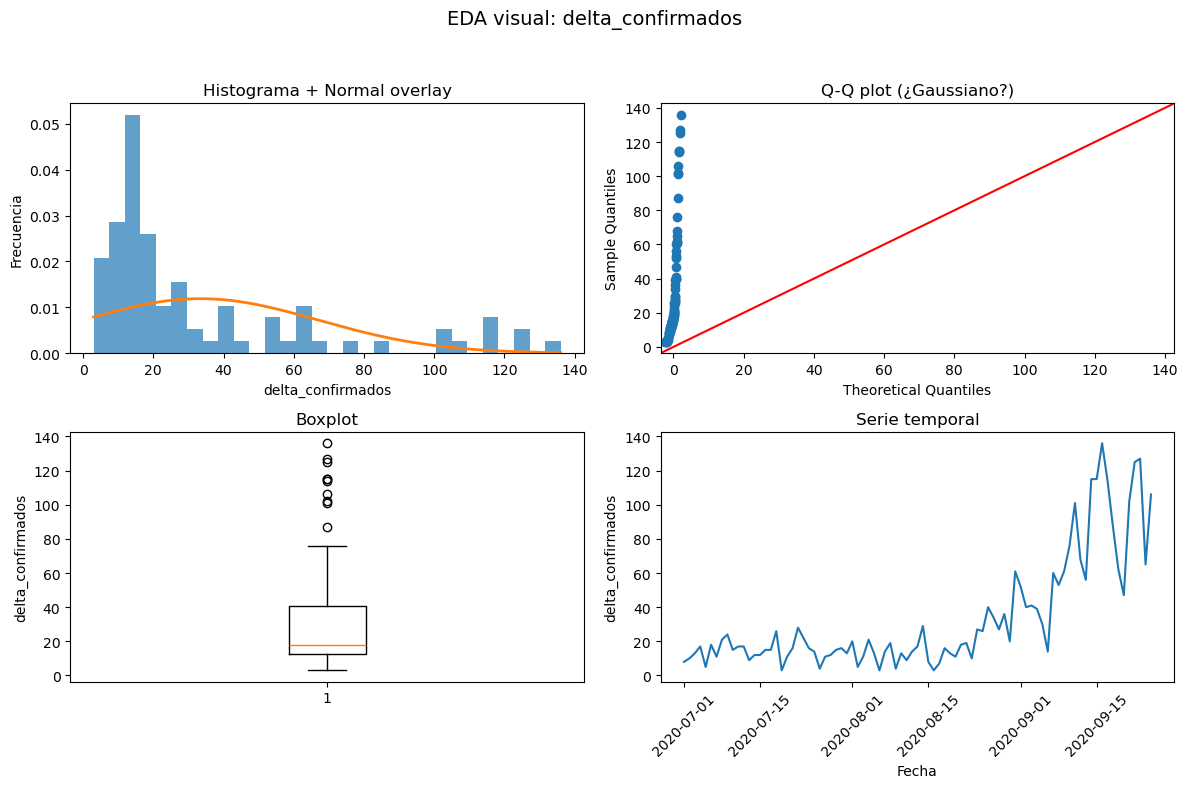

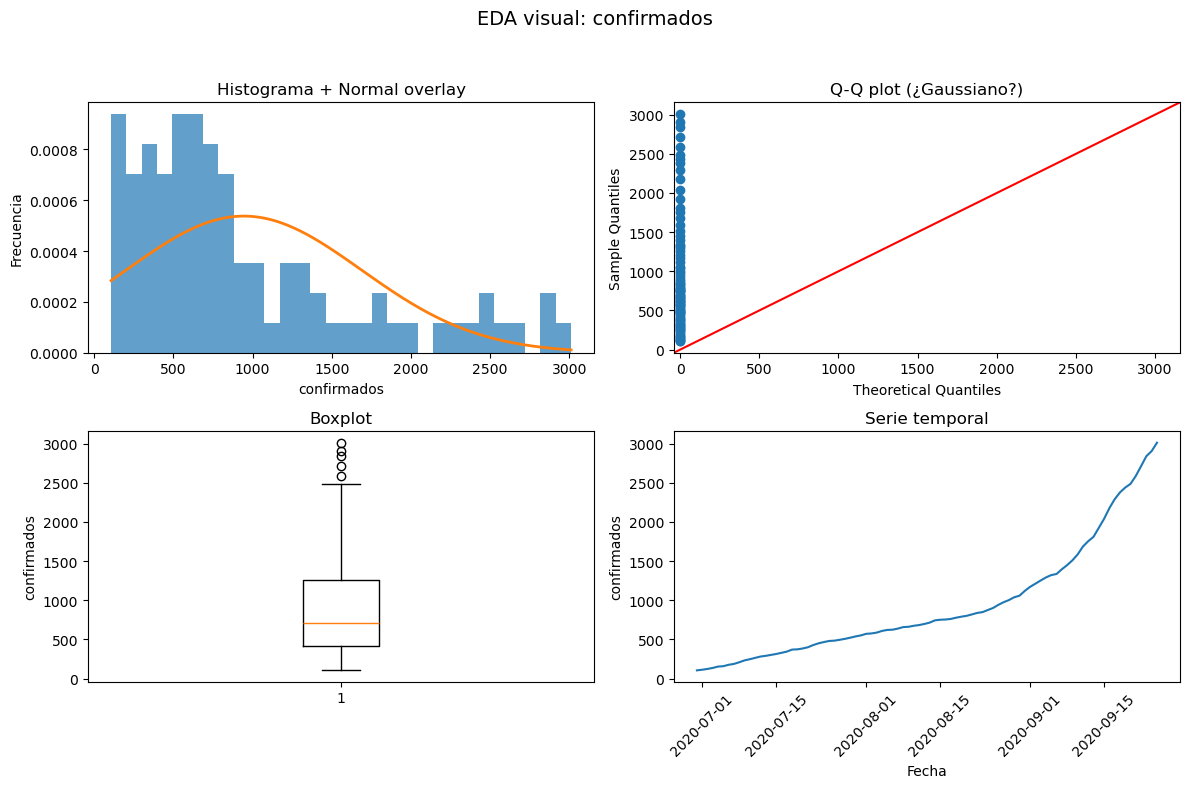

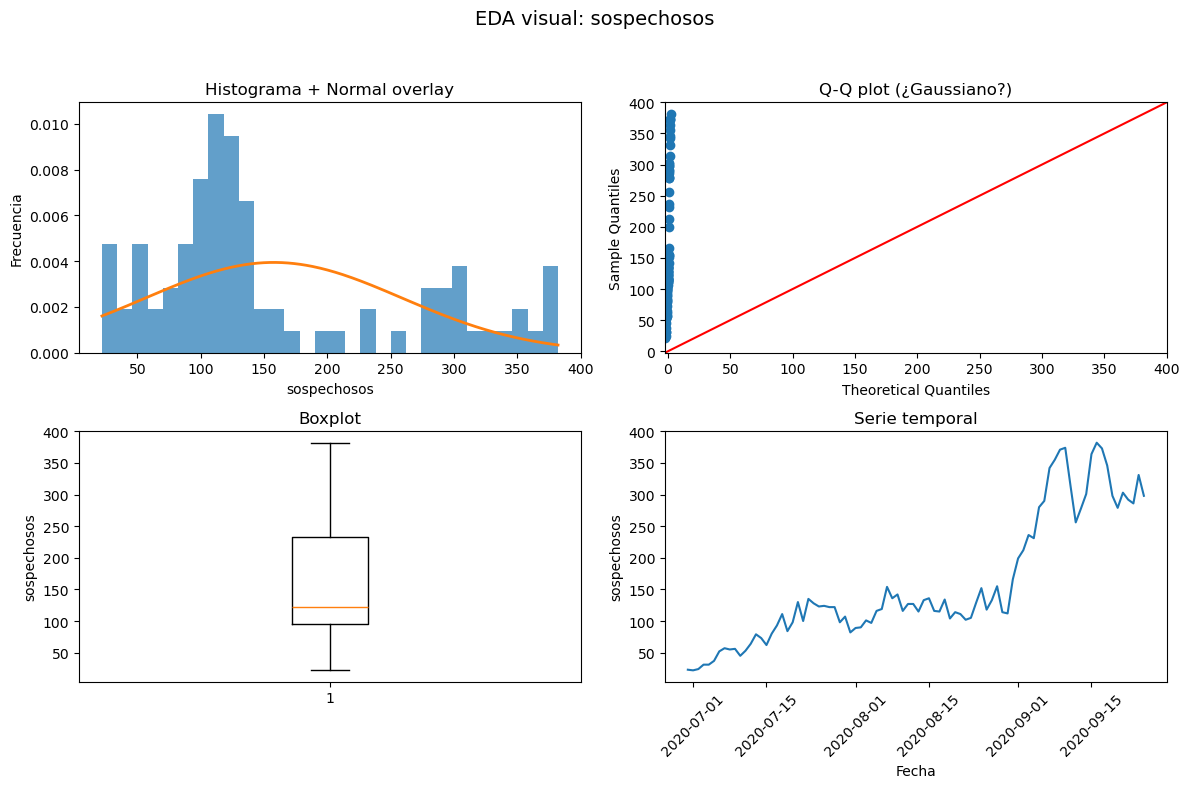

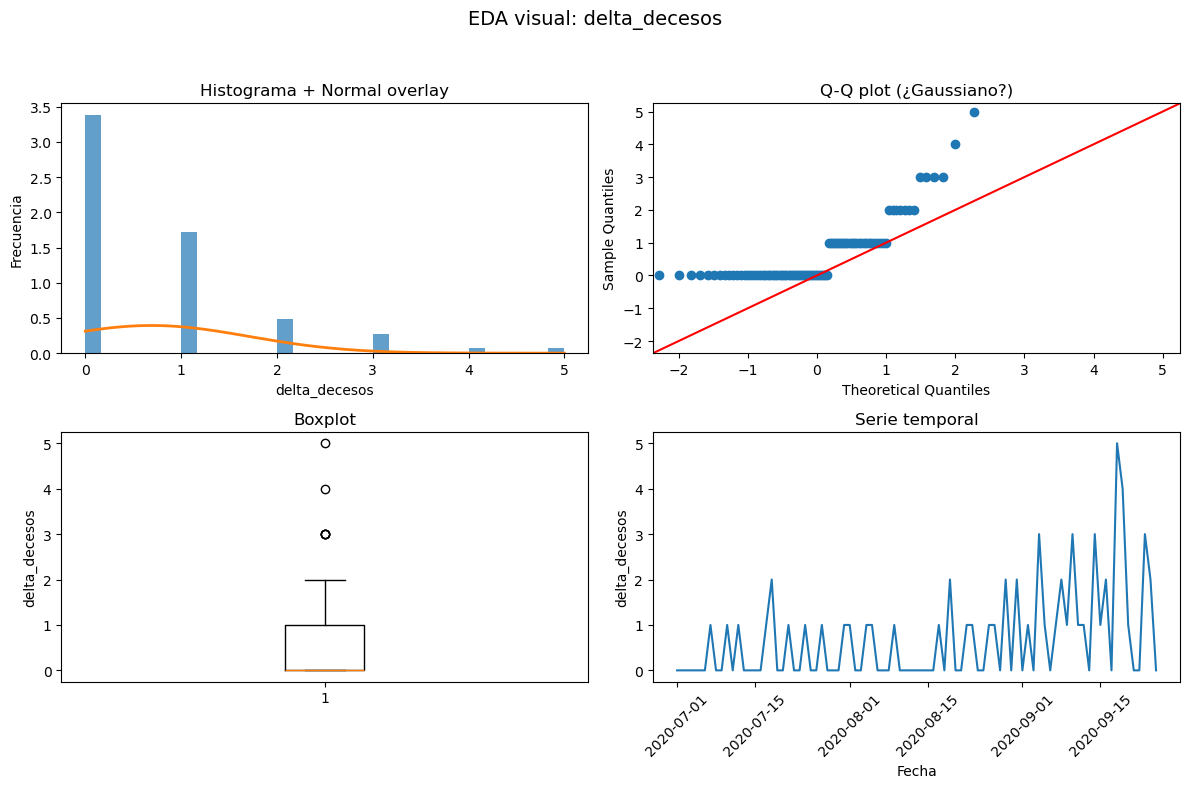

In [26]:
# EDA VISUAL – Dinámica epidemiológica
print("\n Dinámica epidemiológica")
for v in vars_epi:
    if v in df.columns:
        plot_eda_2x2(df, v)


 Sistema de salud


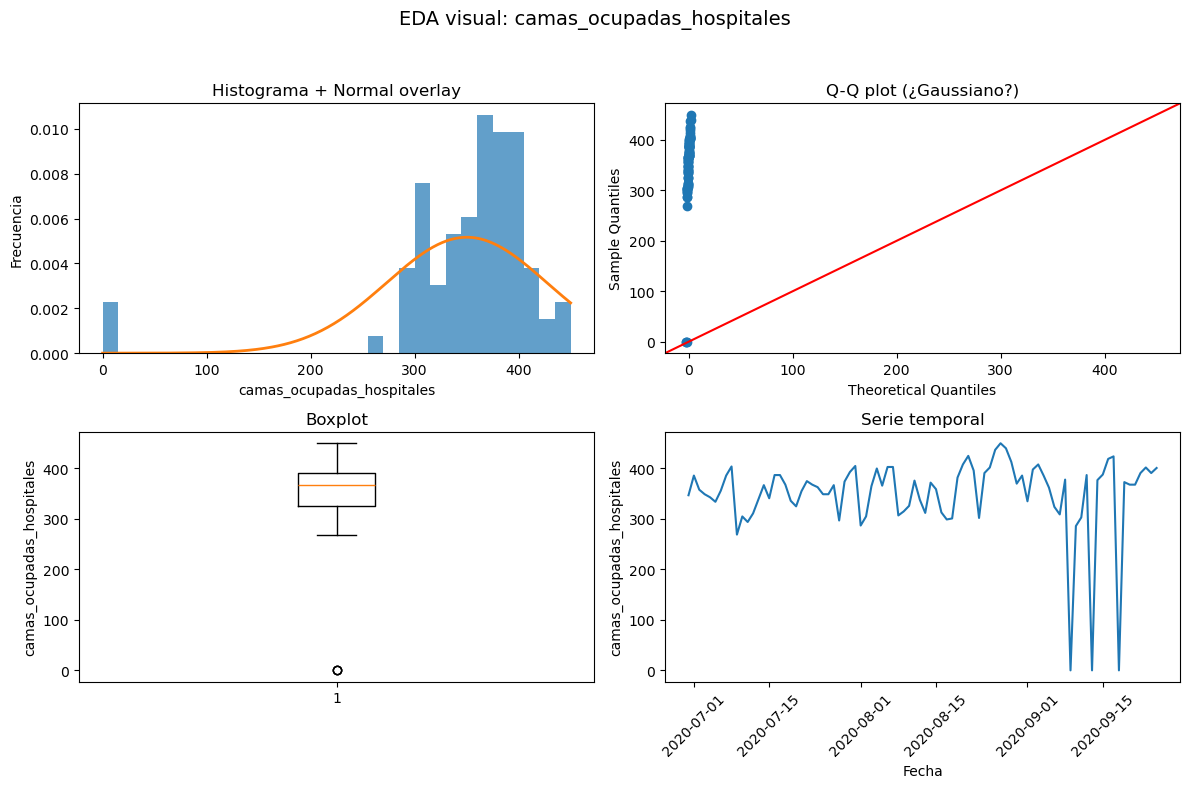

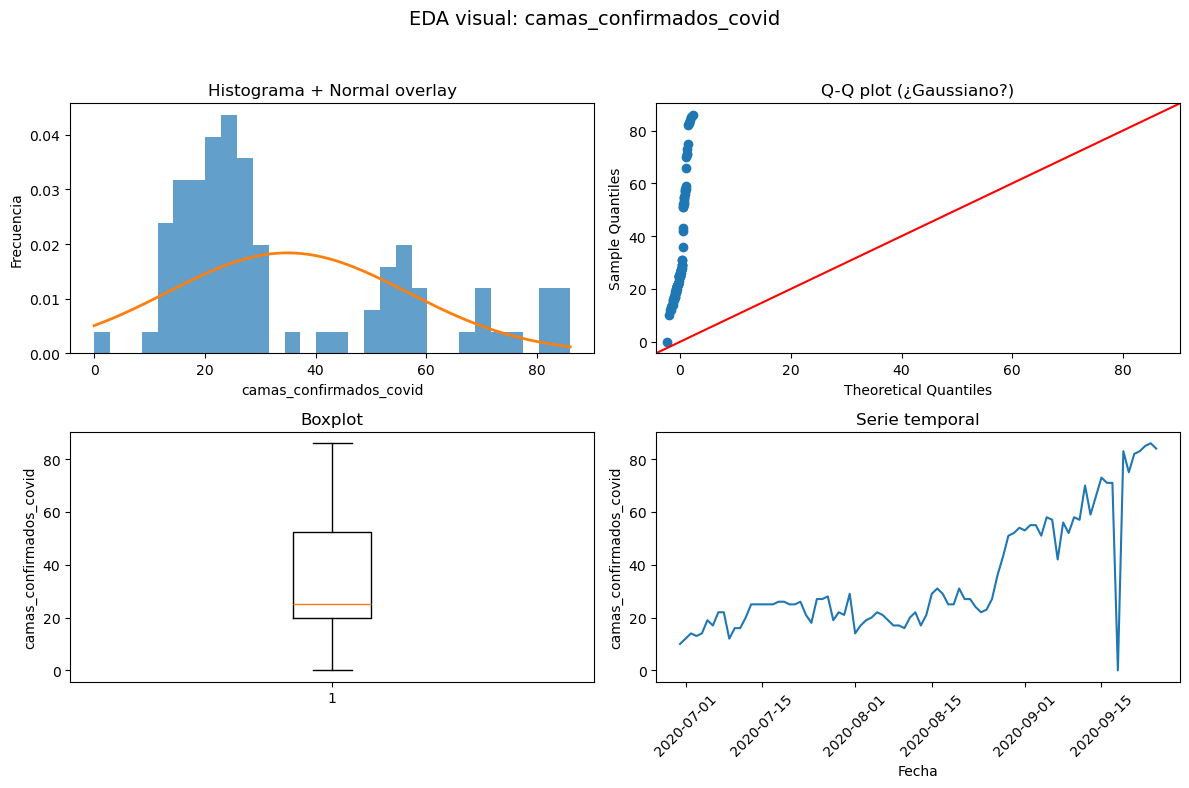

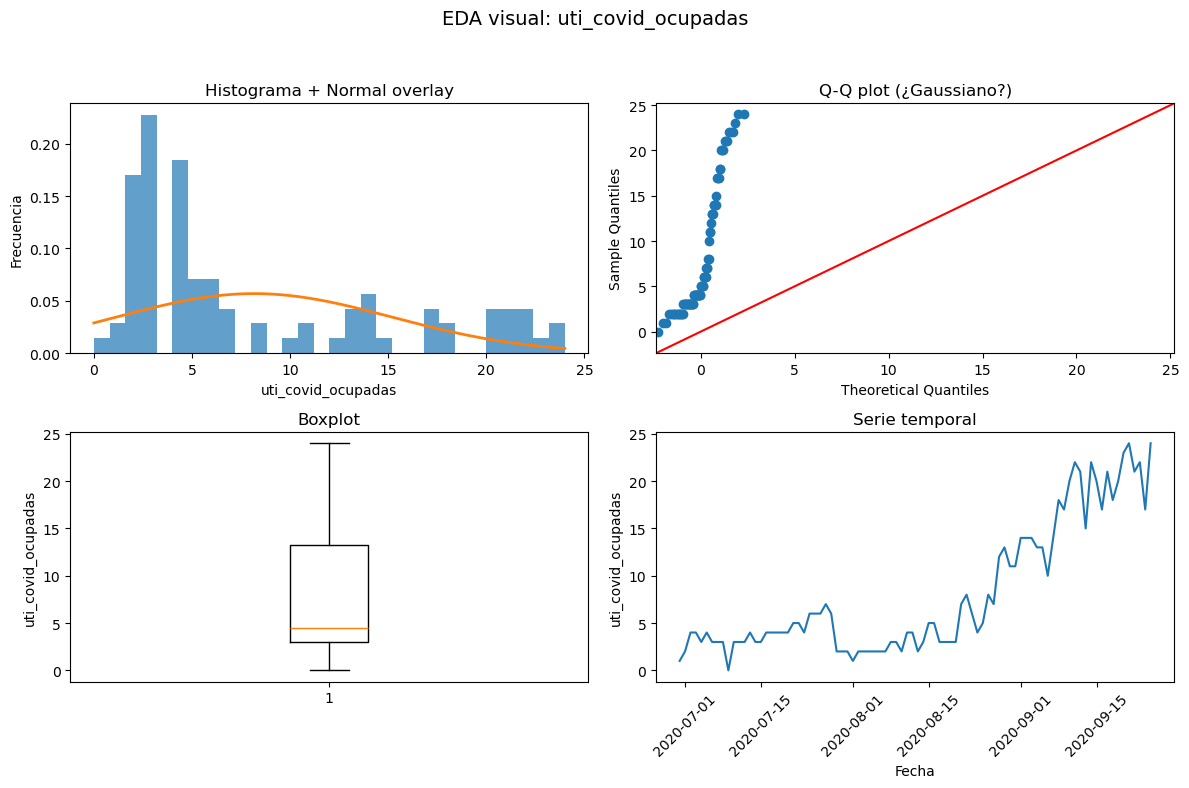

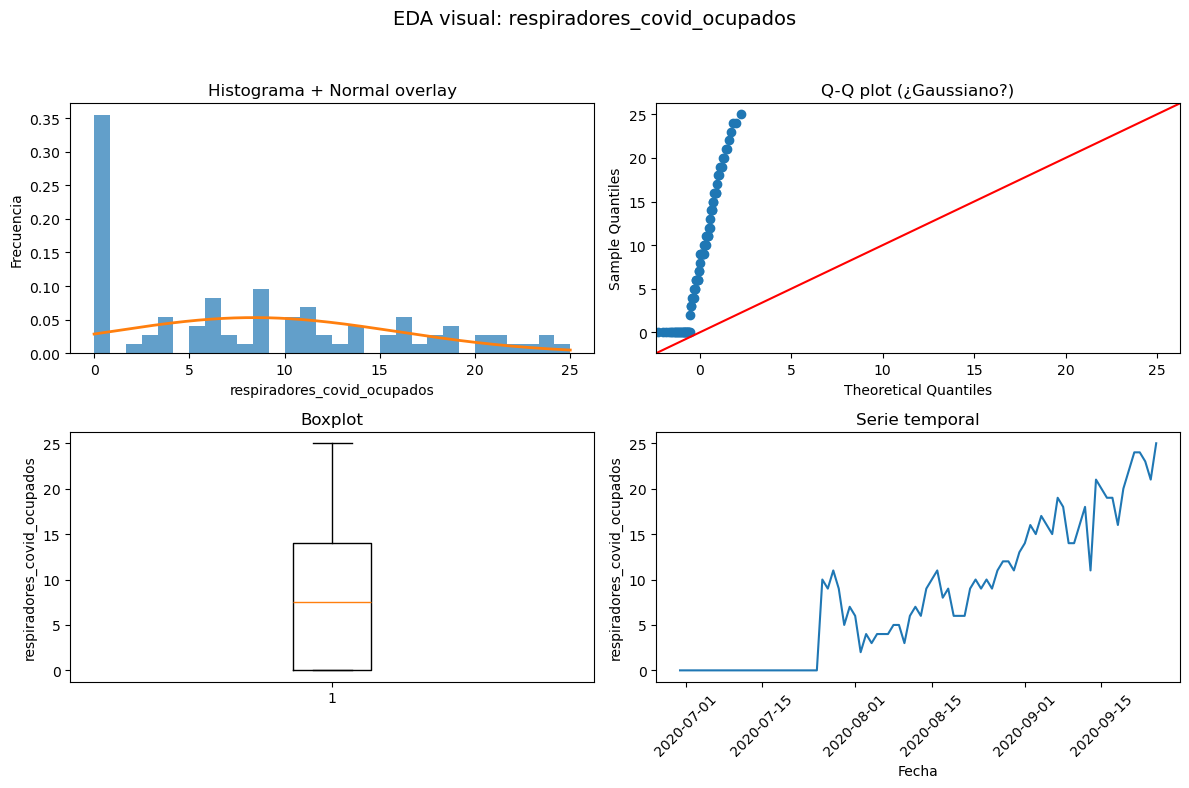

In [27]:
# EDA VISUAL – Sistema de salud
print("\n Sistema de salud")
for v in vars_salud:
    if v in df.columns:
        plot_eda_2x2(df, v)

# Conclusiones

## Interpretación visual y conclusiones del análisis exploratorio
Lr, las variables asociadas a la dinámica epidemiológica, tales como los incrementos diarios de casos confirmados y fallecimientos, así como los conteos acumulados y los casos sospechosos, presentan distribuciones claramente asimétricas, con una marcada concentración de valores bajos y la presencia de picos aislados de gran magnitud. Estas características se reflejan en histogramas con colas derechas prolongadas y en diagramas Q-Q que se apartan sistemáticamente de la recta de referencia, especialmente en los cuantiles extremos. Este comportamiento es consistente con procesos de conteo discretos, sujetos a eventos esporádicos y a una fuerte dependencia temporal, por lo que no resulta razonable asumir normalidad en estas variableLgar, las variables vinculadas a la ocupación del sistema de salud, tales como el número de camas hospitalarias ocupadas, camas destinadas a pacientes confirmados de COVID-19, unidades de terapia intensiva ocupadas y respiradores en uso, exhiben una mayor concentración de valores y una dispersión relativamente más acotada. No obstante, el análisis visual revela que estas variables también se apartan del supuesto de normalidad, mostrando asimetrías moderadas y colas más pesadas de lo esperado bajo una distribución gaussiana. Este comportamiento se explica por la existencia de límites estructurales y operativos en la capacidad del sistema de salud, así como por la dinámica no estacionaria asociada a las distintas olas epidemiológicas.

Asimismo, el examen de los boxplots y de las series temporales permitió identificar valores potencialmente atípicos y patrones discontinuos en algunas variables de ocupación, particularmente caídas abruptas a valores cercanos a cero en fechas puntuales. Dado el contexto epidemiológico y operativo, este tipo de comportamientos no resulta plausible desde el punto de vista del sistema de salud, lo que sugiere la posible presencia de errores  mo cero o cambios en los criterios de registro de la inf (poltíca sanitaria)ormación. Estos hallazgos resaltan la importarealizar la visualización de datos.dística.

En conjunto, la evidencia empírica obtenida a partir de las visualizaciones indica que ninguna de las variables analizadas presenta un comportamiento compatible con una distribución normal en sentido estricto. En consecuencia, el uso de métodos descriptivos basados exclusivamente en la media y la desviación estándar podría conducir a interpretacionesferencia.


# Variables con comportamiento sospechoso

A partir de los boxplots y, principalmente, de las series temporales, se identifican patrones que no son esperables bajo un funcionamiento epidemiológico/operativo normal y que sugieren inconsistencias de registro:

camas_ocupadas_hospitales
Presenta caídas abruptas a valores cercanos a 0 en fechas puntuales. En variables de ocupación hospitalaria esto resulta poco plausible y típicamente indica dato faltante/erróneo.

camas_confirmados_covid
Se observan saltos discontinuos, incluyendo descensos súbitos a 0 o valores anormalmente bajos, incompatibles con la continuidad esperable de un stock de internación. Esto sugiere problemas de calidad de datos.

respiradores_covid_ocupados (condicional)
Si la serie muestra tramos prolongados en 0 seguidos de aumentos bruscos, puede deberse a un cambio de criterio o inicio de registro más que a un fenómeno clínico. Requiere verificación con metadatos/contexto.


Variables como delta_confirmados y delta_decesos pueden exhibir “outliers” en boxplots, pero en general estos corresponden a picos epidemiológicos reales y no necesariamente implican errores de medición.

# ------------------------------------------------------------------

# ------------------------------------------------------------------

# ------------------------------------------------------------------

## Ejercicio 2

Generar un dataset similar al de la pág. 12 del apunte: **dos conjuntos Gaussianos** con diferente **media** y **desviación estándar**, con **N = 50** muestras cada uno.  
Un conjunto debe tener la etiqueta **A** y el otro la etiqueta **B**.

---

### 1) Generación del dataset

- Conjunto **A**:

$$
X_A \sim \mathcal{N}(\mu_A, \sigma_A)
$$

con \(N = 50\).

- Conjunto **B**:

$$
X_B \sim \mathcal{N}(\mu_B, \sigma_B)
$$

con \(N = 50\).

---

### 2) Clasificación por umbral (supervisado)

- Definir un clasificador basado en un **umbral** \(t\).
- Utilizar la **curva ROC** para proponer un umbral que minimice el error (**criterio de mínimo error**).

---

### 3) Evaluación del clasificador

Calcular las siguientes métricas de calidad:

- **Exactitud** (*accuracy*)
- **Precisión** (*precision*)
- **F-measure** (*F1-score*)

---

### 4) Variantes y análisis

Recalcular el análisis para algunas variantes, por ejemplo:

- Acercando las medias de los grupos A y B, generando mayor solapamiento entre las distribuciones.
- Modificando las desviaciones estándar de alguno de los grupos.
- Cambiando el valor del umbral \(t\) y analizando su impacto sobre la curva ROC y las métricas.

---

### 5) Extensión: enfoque no supervisado

**Pregunta:** ¿Cómo podría realizarse este proceso de manera **no supervisada**, es decir, sin utilizar etiquetas?

- Aplicando técnicas de clustering (por ejemplo, *k-means* o *Gaussian Mixture Models*).
- Estimando las distribuciones a partir de los datos y definiendo un umbral en función de los parámetros inferidos.
iniendo un umbral en función de los parámetros inferidos.



In [28]:
mu1, sigma1 = 15, 0.5 # mean and standard deviation
mu2, sigma2 = 17, 0.7 # mean and standard deviation

N = 50

values_1 = np.random.normal(mu1, sigma1, 50)
values_2 = np.random.normal(mu2, sigma2, 50)

In [29]:
def hist_abs_with_gaussian(data, mu, sigma, bins=15, label=None):
    
    # Histograma en frecuencia absoluta
    counts, bin_edges, _ = plt.hist(
        data,
        bins=bins,
        alpha=0.7,
        edgecolor="black",
        label=label
    )

    # Centros de bins
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    # Ancho del bin
    bin_width = bin_edges[1] - bin_edges[0]

    # Gaussiana escalada a frecuencia absoluta
    gaussian = (
        1 / (sigma * np.sqrt(2 * np.pi))
        * np.exp(-(bin_centers - mu) ** 2 / (2 * sigma ** 2))
        * len(data)
        * bin_width
    )

    # Plot gaussiana
    plt.plot(
        bin_centers,
        gaussian,
        linewidth=2,
        color="red"
    )

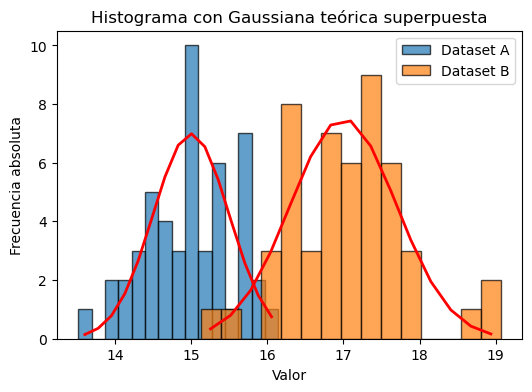

In [30]:
plt.figure(figsize=(6,4))

hist_abs_with_gaussian(values_1, mu1, sigma1, bins=15, label="Dataset A")
hist_abs_with_gaussian(values_2, mu2, sigma2, bins=15, label="Dataset B")

plt.xlabel("Valor")
plt.ylabel("Frecuencia absoluta")
plt.title("Histograma con Gaussiana teórica superpuesta")
plt.legend()
plt.show()

In [31]:
dataset_1 = {
    "values": pd.Series(values_1), 
    "target": "A"
}

df1 = pd.DataFrame(data=dataset_1)

In [32]:
dataset_2 = {
    "values": pd.Series(values_2), 
    "target": "B"
}

df2 = pd.DataFrame(data=dataset_2)

In [33]:
df_final = pd.concat([df1, df2])

In [34]:
df_final

,values,target
0,14.630252,A
1,14.423825,A
2,14.671313,A
3,14.684648,A
4,14.136222,A
...,...,...
45,16.858402,B
46,16.406461,B
47,15.430605,B
48,16.976128,B


In [35]:
df_final["y_true"] = (df_final["target"] == "B").astype(int)

In [36]:
sorted_df = df_final.sort_values(by="values").reset_index(drop=True)
sorted_df

,values,target,y_true
0,13.516722,A,0
1,13.948391,A,0
2,14.011989,A,0
3,14.094852,A,0
4,14.136222,A,0
...,...,...,...
95,17.769177,B,1
96,17.938091,B,1
97,18.645995,B,1
98,19.037647,B,1


In [37]:
# score continuo
y_scores = sorted_df["values"].values
y_true = sorted_df["y_true"].values

In [38]:
def roc_and_min_error_threshold(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores, drop_intermediate=False)
    # error(t) = pi0*FPR + pi1*(1-TPR); con pi0=pi1=0.5 es proporcional a FPR + (1-TPR)
    err = fpr + (1 - tpr)
    idx = np.argmin(err)
    t_star = thresholds[idx]
    return fpr, tpr, thresholds, t_star

In [39]:
def metrics_at_threshold(y_true, scores, t):
    y_pred = (scores >= t).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)  # [[TN, FP],[FN, TP]]
    return {
        "threshold": t, 
        "accuracy": acc, 
        "precision": prec, 
        "f1": f1, 
        "cm": cm
    }

In [40]:
def plot_roc(fpr, tpr, roc_auc, title="ROC"):
    plt.figure(figsize=(5,5))
    plt.plot(fpr, tpr, linewidth=2, label=f"AUC={roc_auc:.3f}")
    plt.plot([0,1],[0,1], "k--", linewidth=1)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [41]:
def plot_scores_xy(scores, y_true, t, title="Scores en plano (x,y) + umbral"):
    y_aux = y_true.astype(float)  # eje auxiliar
    plt.figure(figsize=(7,4))
    plt.scatter(scores[y_true==0], y_aux[y_true==0], alpha=0.7, label="A (0)")
    plt.scatter(scores[y_true==1], y_aux[y_true==1], alpha=0.7, label="B (1)")
    plt.axvline(t, color="black", linestyle="--", linewidth=2, label=f"t*={t:.3f}")
    plt.yticks([0,1], ["A","B"])
    plt.xlabel("score (values)")
    plt.ylabel("clase (eje auxiliar)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [42]:
fpr, tpr, thr, t_star = roc_and_min_error_threshold(y_true, y_scores)
roc_auc = auc(fpr, tpr)

Umbral mínimo error t* = 15.921179308398175
{'threshold': np.float64(15.921179308398175), 'accuracy': 0.96, 'precision': 0.96, 'f1': 0.96, 'cm': array([[48,  2],
       [ 2, 48]])}


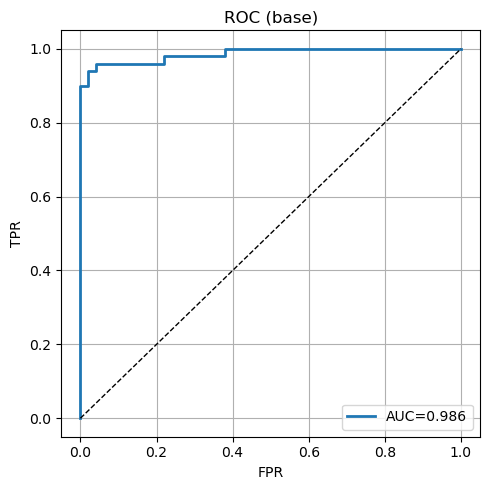

In [43]:
print("Umbral mínimo error t* =", t_star)
print(metrics_at_threshold(y_true, y_scores, t_star))

plot_roc(fpr, tpr, roc_auc, title="ROC (base)")

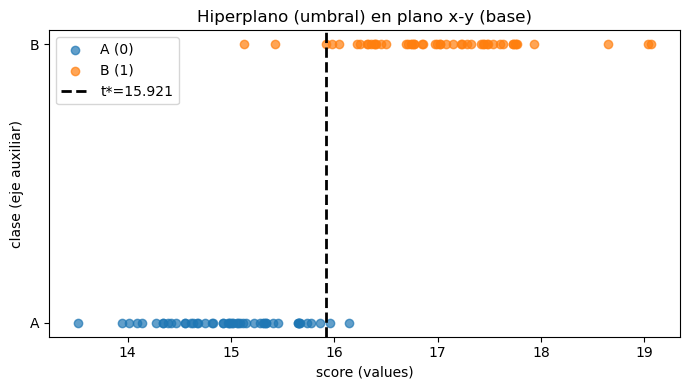

In [44]:
plot_scores_xy(y_scores, y_true, t_star, title="Hiperplano (umbral) en plano x-y (base)")

# VARIANTES: acercar medias y cambiar umbral

In [45]:
variants = [
    {
        "name": "Base", 
        "mu2": 17, 
        "sigma2": 0.7
    },
    {
        "name": "Más difícil (medias más cercanas)", 
        "mu2": 16.5, 
        "sigma2": 0.7
    },
    {
        "name": "Más fácil (medias más separadas)", 
        "mu2": 17.5, 
        "sigma2": 0.7
    },
]

In [46]:
rows = []
for i, v in enumerate(variants):

    values_2 = np.random.normal(v["mu2"], v["sigma2"], 50)

    dataset_2 = {
        "values": pd.Series(values_2), 
        "target": "B"
    }

    df2 = pd.DataFrame(data=dataset_2)

    df_final = pd.concat([df1, df2])

    df_final["y_true"] = (df_final["target"] == "B").astype(int)

    sorted_df = df_final.sort_values(by="values").reset_index(drop=True)

    y_scores = sorted_df["values"].values
    
    y_true = sorted_df["y_true"].values

    fpr, tpr, thr, t_star = roc_and_min_error_threshold(y_true, y_scores)
    
    roc_auc = auc(fpr, tpr)

    # Métricas con t* y con umbral "movido" para ver efecto
    m_star = metrics_at_threshold(y_true, y_scores, t_star)
    m_shift = metrics_at_threshold(y_true, y_scores, t_star + 0.25)  # ejemplo de cambio manual

    rows.append({
        "escenario": v["name"],
        "mu2": v["mu2"],
        "sigma2": v["sigma2"],
        "AUC": roc_auc,
        "t*": m_star["threshold"],
        "acc(t*)": m_star["accuracy"],
        "prec(t*)": m_star["precision"],
        "f1(t*)": m_star["f1"],
        "acc(t*+0.25)": m_shift["accuracy"],
        "prec(t*+0.25)": m_shift["precision"],
        "f1(t*+0.25)": m_shift["f1"],
    })

summary = pd.DataFrame(rows)
print("\n=== Resumen de variantes ===")
print(summary.to_string(index=False))


=== Resumen de variantes ===
                        escenario  mu2  sigma2    AUC       t*  acc(t*)  prec(t*)   f1(t*)  acc(t*+0.25)  prec(t*+0.25)  f1(t*+0.25)
                             Base 17.0     0.7 0.9960 15.96285     0.97  0.979592 0.969697          0.94            1.0     0.936170
Más difícil (medias más cercanas) 16.5     0.7 0.9580 15.96125     0.92  0.977273 0.914894          0.88            1.0     0.863636
 Más fácil (medias más separadas) 17.5     0.7 0.9996 16.10738     0.99  0.980392 0.990099          0.98            1.0     0.979592


# Conclusión

Los resultados muestran que, al aumentar la separación entre las medias de las clases, la capacidad del clasificador mejora significativamente, reflejada en un AUC cercano a 1 y métricas de exactitud, precisión y F1 prácticamente perfectas. Cuando las medias se acercan, el solapamiento entre las distribuciones aumenta, lo que reduce el desempeño y vuelve al umbral óptimo más sensible a pequeñas variaciones. En todos los escenarios, el umbral obtenido por el criterio de mínimo error maximiza el compromiso entre falsos positivos y falsos negativos, mientras que desviarse de dicho umbral degrada las métricas, especialmente en los casos con mayor solapamiento.

# Hacer no supervisado el proceso

In [47]:
mu1, sigma1 = 15, 0.5 # mean and standard deviation
mu2, sigma2 = 17, 0.7 # mean and standard deviation

values_1 = np.random.normal(mu1, sigma1, 50)
values_2 = np.random.normal(mu2, sigma2, 50)

dataset_1 = {
    "values": pd.Series(values_1), 
    "target": "A"
}

dataset_2 = {
    "values": pd.Series(values_2), 
    "target": "B"
}

df2 = pd.DataFrame(data=dataset_2)

df_final = pd.concat([df1, df2])

df_final["y_true"] = (df_final["target"] == "B").astype(int)

sorted_df = df_final.sort_values(by="values").reset_index(drop=True)

y_scores = sorted_df["values"].values

y_true = sorted_df["y_true"].values

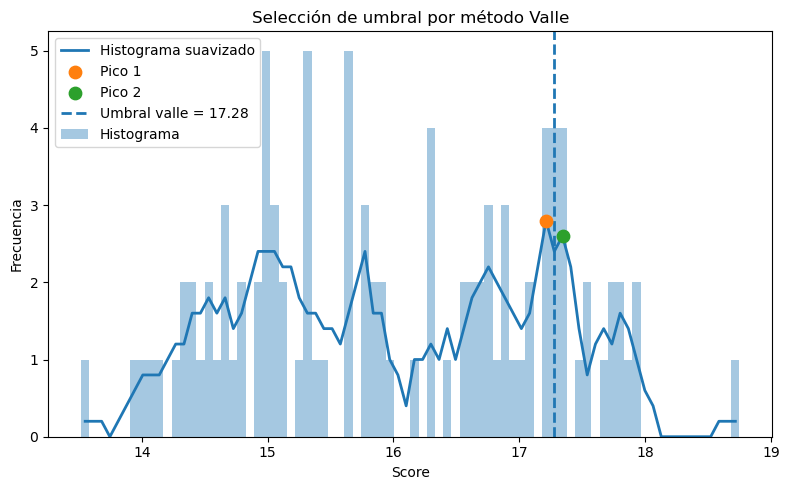

Umbral valle: 17.27821926035034


In [48]:
smooth_k=5
nbins=80

v = np.asarray(y_scores)
v = v[np.isfinite(v)]

hist, bin_edges = np.histogram(v, bins=nbins)
centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Suavizado (media móvil)
kernel = np.ones(smooth_k) / smooth_k
h_smooth = np.convolve(hist, kernel, mode="same")

# Dos picos principales
peak_idxs = np.argsort(h_smooth)[-2:]
peak_idxs = np.sort(peak_idxs)
i1, i2 = peak_idxs

# Valle entre picos
valley_idx = i1 + np.argmin(h_smooth[i1:i2 + 1])
t_valley = centers[valley_idx]

plt.figure(figsize=(8, 5))

# Histograma (barras)
plt.bar(
    centers,
    hist,
    width=(centers[1] - centers[0]),
    alpha=0.4,
    label="Histograma"
)

# Histograma suavizado
plt.plot(centers, h_smooth, linewidth=2, label="Histograma suavizado")

# Picos
plt.scatter(centers[i1], h_smooth[i1], s=80, zorder=3, label="Pico 1")
plt.scatter(centers[i2], h_smooth[i2], s=80, zorder=3, label="Pico 2")

# Valle (umbral)
plt.axvline(t_valley, linestyle="--", linewidth=2, label=f"Umbral valle = {t_valley:.2f}")

plt.xlabel("Score")
plt.ylabel("Frecuencia")
plt.title("Selección de umbral por método Valle")
plt.legend()
plt.tight_layout()
plt.show()

print("Umbral valle:", t_valley)

# Método del Valle
El método del valle selecciona el umbral en el mínimo local de la densidad entre los dos picos principales de la distribución.

## Fundamento

Si los datos provienen de dos poblaciones distintas, la densidad empírica suele presentar dos máximos (picos) separados por una región de baja densidad (valle). Dicho valle representa el punto de menor ambigüedad entre clases.

El umbral se ubica donde la probabilidad de pertenecer a una u otra clase es mínima, separando ambos datasets de forma intuitiva y geométrica.

# --------------------------------------------------------

# --------------------------------------------------------

# Ejercicio 3 (optativo):

1. Cómo serían los pasos si el dataset fuese 2D?
2. Puedo utilizar la curva ROC sin ninguna estimación previa?
3. Caso negativo, qué estimación sería útil (y cómo obtenerla)?

In [49]:
# Creamos dataset

mu_A = [25, 2]     # centro de A
sigma_A = [3, 1]  # dispersión de A

mu_B = [33, 3]     # centro de B
sigma_B = [4, 1]   # dispersión de B

N = 50

rng = np.random.default_rng(42)

# Clase A
XA = rng.normal(loc=mu_A, scale=sigma_A, size=(N, 2))
XA = np.rint(XA).astype(int)   # redondear a enteros

# Clase B
XB = rng.normal(loc=mu_B, scale=sigma_B, size=(N, 2))
XB = np.rint(XB).astype(int)

data = []

for x, y in XA:
    data.append(("A", x, y))

for x, y in XB:
    data.append(("B", x, y))

df = pd.DataFrame(data, columns=["target", "X", "Y"])

In [50]:
df

,target,X,Y
0,A,26,1
1,A,27,3
2,A,19,1
3,A,25,2
4,A,25,1
...,...,...,...
95,B,40,3
96,B,31,4
97,B,29,2
98,B,36,3


### Los datos fueron generados a partir de dos distribuciones gaussianas bidimensionales, una por clase. Las muestras obtenidas se redondearon a valores enteros para reproducir el formato del dataset original.

Cada clase puede representarse por su **centroide**, definido como el promedio de sus observaciones:

$$
\mu_A = \frac{1}{N_A}\sum_{i \in A} x_i,
\qquad
\mu_B = \frac{1}{N_B}\sum_{i \in B} x_i
$$

La **distancia euclídea** mide qué tan cerca se encuentra un punto respecto de cada centroide.

Clasificar por distancia equivale a asignar cada observación a la clase cuyo centroide está más próximo. Esta regla induce una **frontera de decisión** que corresponde a la **mediatriz del segmento** que une ambos centroides.


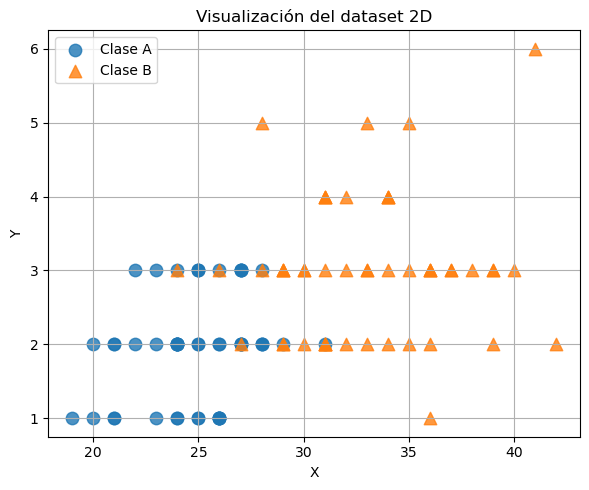

In [51]:
# Primero realizamos una visualización de datos

# Separar clases
df_A = df[df["target"] == "A"]
df_B = df[df["target"] == "B"]

plt.figure(figsize=(6, 5))

plt.scatter(df_A["X"], df_A["Y"], marker="o", s=80, label="Clase A", alpha=0.8)
plt.scatter(df_B["X"], df_B["Y"], marker="^", s=80, label="Clase B", alpha=0.8)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Visualización del dataset 2D")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretación 

1. Existe una separación parcial entre las clases, principalmente a lo largo del eje X.
2. Se observa una región de solapamiento alrededor de 𝑋 ≈ 27 – 30, donde ambas clases coexisten. La separación no es perfecta, pero es "cuasi" lineal.

In [52]:
# Aplicamos distancia a centroides

X = df[["X", "Y"]].to_numpy()
y_true = (df["target"] == "B").astype(int).to_numpy()  # B=1, A=0

# se calculan centroides
mu_A = X[y_true == 0].mean(axis=0)
mu_B = X[y_true == 1].mean(axis=0)

# Importante:

La curva ROC no trabaja sobre "vectores de características", sino sobre scores (puntuaciones) asociados a una decisión binaria.

Entonces, se procede a realizar una estimación del "scoring", a partir del calculo de las distancias euclidea a los centroides.

Clasificar por distancia equivale a asignar cada observación a la clase cuyo centroide está más próximo, lo que induce una frontera de decisión que es la recta ortogonal del segmento que une ambos centroides.

In [53]:
# Se define score (distancia relativa)
# score > 0 => más cerca de B
dA = np.linalg.norm(X - mu_A, axis=1)
dB = np.linalg.norm(X - mu_B, axis=1)

scores = dA - dB

In [54]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

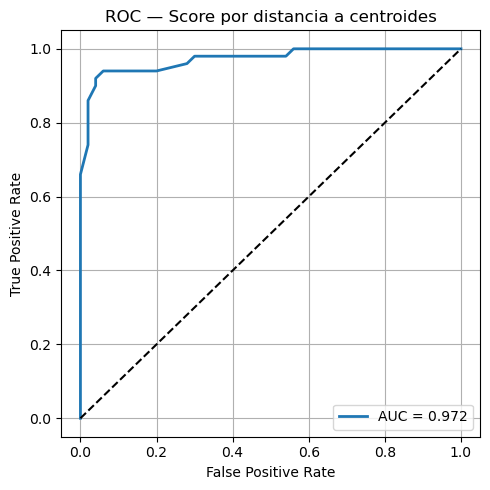

In [55]:
# Plot ROC
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Score por distancia a centroides")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Interpretación de la curva ROC — Score por distancia a centroides

La curva ROC obtenida a partir del score definido como la diferencia de distancias a los centroides de cada clase presenta un AUC ≈ 0.97, lo que indica una muy alta capacidad discriminativa del criterio utilizado.

1. La curva se eleva rápidamente hacia valores altos de TPR con FPR bajos.